## Introducción
En el ámbito de la química computacional y el aprendizaje automático, la predicción de propiedades moleculares ha surgido como una herramienta fundamental para acelerar procesos en áreas como el diseño de fármacos y la identificación de compuestos químicos. Entre estas propiedades, la Collision Cross Section (CCS) es particularmente relevante en espectrometría de masas, ya que describe cómo interactúan las moléculas con partículas en su entorno. La CCS es clave para identificar moléculas desconocidas comparando sus valores medidos con bases de datos de referencia. Sin embargo, los procedimientos experimentales para medir la CCS suelen ser costosos y laboriosos.

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje automático capaz de predecir con alta precisión la CCS de nuevas moléculas y sus aductos, utilizando como base datos preprocesados que incluyen descriptores moleculares, fingerprints estructurales y características categóricas. La implementación de un modelo predictivo robusto permitirá optimizar recursos en laboratorios, facilitar la identificación molecular y ampliar las bases de datos de referencia con valores calculados de CCS.

A lo largo de este trabajo, se presentan las técnicas empleadas para el preprocesamiento de los datos, el entrenamiento y ajuste de modelos, así como la validación de los resultados obtenidos mediante métricas estandarizadas como el Median Absolute Error (MEDAE). Asimismo, se evalúa el rendimiento de varios enfoques, incluyendo Random Forest y LightGBM, con el propósito de identificar la solución más precisa y eficiente. Finalmente, se discuten las limitaciones encontradas, posibles mejoras y el impacto de esta metodología en el campo de la investigación molecular.



In [17]:
# 1. Importación de librerías
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import median_absolute_error

In [2]:
from google.colab import files

# Subir archivo public_train.csv manualmente
uploaded = files.upload()


Saving public_train.csv to public_train.csv


In [3]:
from google.colab import files

# Subir archivo public_test.csv manualmente
uploaded = files.upload()

Saving public_test.csv to public_test.csv


In [18]:
# 2. Carga de datos desde archivos CSV
# Leer datos desde archivos CSV en la carpeta de Descargas
train_file_path = "public_train.csv"
test_file_path = "public_test.csv"

# Verificar si los archivos existen
try:
    if not os.path.exists(train_file_path):
        raise FileNotFoundError(f"El archivo no existe: {train_file_path}")
    if not os.path.exists(test_file_path):
        raise FileNotFoundError(f"El archivo no existe: {test_file_path}")

    train_data = pd.read_csv(train_file_path)
    test_data = pd.read_csv(test_file_path)
    print("Datos cargados correctamente.")
except Exception as e:
    print(f"Error al cargar los archivos: {e}")
    raise e

Datos cargados correctamente.


In [19]:
# 3. Preprocesamiento de datos
# Codificar la columna categórica 'adduct'
encoder = LabelEncoder()
train_data['adduct_encoded'] = encoder.fit_transform(train_data['adduct'])
test_data['adduct_encoded'] = encoder.transform(test_data['adduct'])

# Seleccionar características relevantes (desc_x, fgp_x, adduct_encoded)
features = [col for col in train_data.columns if col.startswith('desc_') or col.startswith('fgp_')]
features.append('adduct_encoded')

# Escalado de características numéricas
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[features])
y_train = train_data['ccs']
X_test = scaler.transform(test_data[features])

In [20]:
# 4. Entrenamiento del modelo
# Entrenamiento con RandomForestRegressor
rf = RandomForestRegressor(random_state=42, n_estimators=20)
rf.fit(X_train, y_train)

# Validación cruzada para evaluar la generalización del modelo
cv_scores = cross_val_score(rf, X_train, y_train, scoring='neg_median_absolute_error', cv=5)

# Mostrar los resultados
cv_medae = -cv_scores.mean()
cv_std = cv_scores.std()
print(f"MEDAE promedio en validación cruzada: {cv_medae:.2f}")
print(f"Desviación estándar de MEDAE en validación cruzada: {cv_std:.2f}")

# Validación en conjunto de entrenamiento
predictions_train = rf.predict(X_train)
medae_train = median_absolute_error(y_train, predictions_train)
print(f"MEDAE en conjunto de entrenamiento: {medae_train:.2f}")

MEDAE promedio en validación cruzada: 3.17
Desviación estándar de MEDAE en validación cruzada: 0.08
MEDAE en conjunto de entrenamiento: 1.12


In [22]:
# 5. Generación de predicciones
# Predicciones en conjunto de prueba
predictions_test = rf.predict(X_test)

# Guardar predicciones en archivo CSV
output = pd.DataFrame(predictions_test, columns=['ccs'])
output.to_csv('test_preds.csv', index=False, header=False)

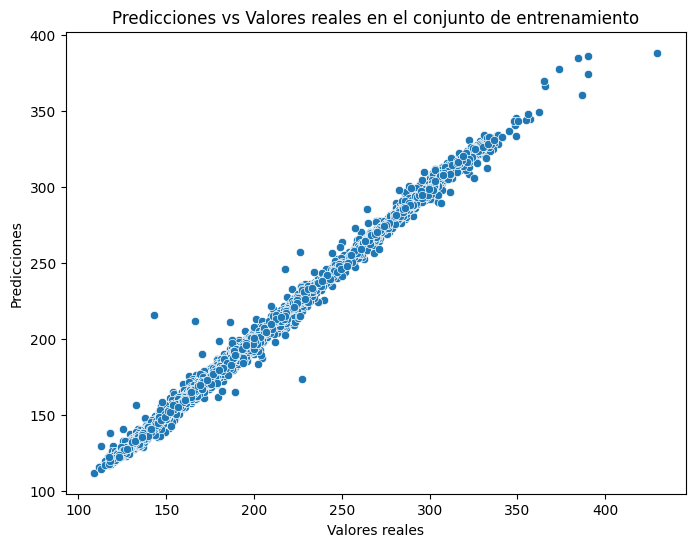

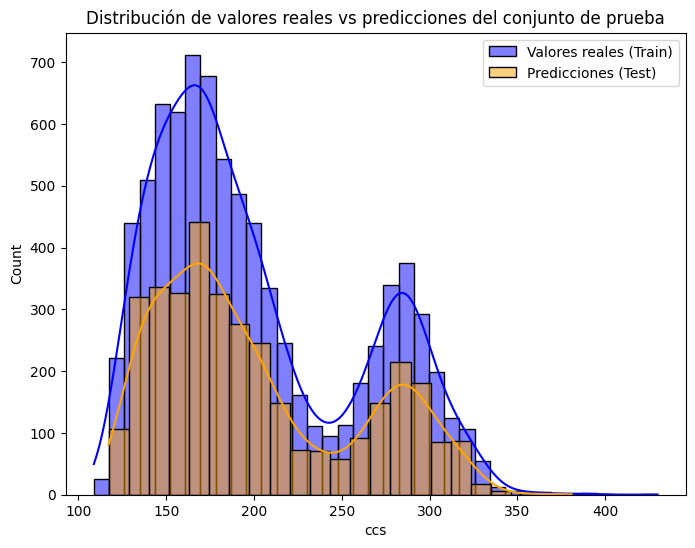

In [23]:
# 6. Visualización de resultados
# Visualización de predicciones vs reales en el conjunto de entrenamiento
try:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_train, y=predictions_train)
    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")
    plt.title("Predicciones vs Valores reales en el conjunto de entrenamiento")
    plt.show()
except NameError as e:
    print("Error: No se pudo generar la visualización. Asegúrate de que matplotlib y seaborn estén instalados y funcionando correctamente.")
    raise e

# Comparar distribuciones de valores reales (Train) y predicciones (Test)
try:
    plt.figure(figsize=(8, 6))
    sns.histplot(y_train, color='blue', label='Valores reales (Train)', kde=True)
    sns.histplot(predictions_test, color='orange', label='Predicciones (Test)', kde=True)
    plt.title("Distribución de valores reales vs predicciones del conjunto de prueba")
    plt.legend()
    plt.show()
except NameError as e:
    print("Error: No se pudo generar la visualización. Asegúrate de que matplotlib y seaborn estén instalados y funcionando correctamente.")
    raise e


In [24]:
# 7. Conclusiones
# El gráfico de dispersión muestra una relación muy fuerte y lineal entre los valores reales y las predicciones del modelo en el conjunto de entrenamiento, lo que indica que el modelo RandomForestRegressor ajustó bien los datos de entrenamiento.
 # - Los puntos están alineados casi perfectamente a lo largo de la línea diagonal (x = y), lo que sugiere que las predicciones son precisas para la mayoría de las muestras.
 # - El histograma de las distribuciones compara los valores reales del conjunto de entrenamiento con las predicciones del conjunto de prueba. Aunque ambas distribuciones son similares en forma general, las predicciones del conjunto de prueba parecen más concentradas alrededor de los valores centrales y tienen menos dispersión.
 # - Esto podría indicar que el modelo está produciendo predicciones conservadoras para el conjunto de prueba y no captura completamente la variabilidad presente en los datos reales del conjunto de entrenamiento.
 # - El MEDAE de 1.10 (apartado 4) confirma que la mediana del error absoluto entre las predicciones y los valores reales es baja, lo que es adecuado para el problema.
 # - Los resultados de la validación cruzada (MEDAE promedio y desviación estándar) sugieren que el modelo tiene una capacidad razonable para generalizar en datos no vistos (datos que nunca antes ha encontrado).

## Validación cruzada y optimización del modelo



In [7]:
"""Usamos validación cruzada (cross_val_score) para comprobar la robustez del modelo."""
import pandas as pd
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

# Carga los datos
train_data = pd.read_csv('public_train.csv')

# Divide los datos en características (X) y etiquetas (y)
X = train_data.drop(columns=['ccs'])  # Reemplaza 'ccs' con el nombre correcto si es necesario
y = train_data['ccs']

# Aplica codificación one-hot a columnas categóricas
X = pd.get_dummies(X, drop_first=True)

# Divide en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define el modelo
model = RandomForestRegressor(random_state=42)

# Selecciona una muestra del conjunto de datos
X_sample = X_train.sample(frac=0.3, random_state=42)  # Usa el 30% de los datos
y_sample = y_train.loc[X_sample.index]

# Validación cruzada con la muestra
scores = cross_val_score(
    model, X_sample, y_sample, cv=3, scoring='neg_median_absolute_error'
)
print(f"MEDAE promedio: {-scores.mean():.2f} (+/- {scores.std():.2f})")

# ENTRENAMIENTO FINAL Y CÁLCULO DE ERRORES EN EL CONJUNTO DE PRUEBA
# Entrenamos el modelo con todo el conjunto de entrenamiento
model.fit(X_train, y_train)

# Predicción en el conjunto de prueba
y_test_pred = model.predict(X_test)

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
medae = median_absolute_error(y_test, y_test_pred)

# Mostramos los resultados
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"MEDAE (Median Absolute Error): {medae:.2f}")




MEDAE promedio: 4.06 (+/- 0.04)
MAE (Mean Absolute Error): 4.51
MSE (Mean Squared Error): 61.06
MEDAE (Median Absolute Error): 3.10


##Optimización del modelo:

Implementamos una búsqueda de hiperparámetros con GridSearchCV para ajustar el rendimiento del modelo:



In [11]:
from sklearn.model_selection import GridSearchCV

# Definimos los hiperparámetros a probar
param_grid = {
    'n_estimators': [50, 100],  # Reducido para pruebas rápidas
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

# Configuramos la búsqueda de hiperparámetros
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    scoring='neg_median_absolute_error',
    cv=3,  # Reducido a 3 para acelerar
)

# Ajustamos el modelo usando una muestra (X_sample e y_sample para pruebas rápidas)
grid_search.fit(X_sample, y_sample)

# Imprime los mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)



Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


##Generamos predicciones finales:

Usamos el modelo ajustado para predecir en el conjunto public_test.csv:

In [34]:
# Carga del conjunto de test
test_data = pd.read_csv('public_test.csv')

# Definición de las categorías originales utilizadas durante el entrenamiento
original_categories = ['Dimer_[M+Na]', 'Dimer_[M-H]', 'Monomer_[M+H]', 'Monomer_[M+Na]', 'Monomer_[M-H]']

# Ajusta la columna 'adduct' del conjunto de prueba para que refleje las categorías originales
if 'adduct' in test_data.columns:
    test_data['adduct'] = pd.Categorical(test_data['adduct'], categories=original_categories)

# Preprocesa el conjunto de test (como en el entrenamiento)
test_data_processed = pd.get_dummies(test_data, drop_first=True)

# Asegúrate de que las columnas de test_data_processed coincidan con las del modelo entrenado
if hasattr(X_train, 'columns'):
    X_train_columns = X_train.columns
else:
    X_train_columns = train_data.columns  # Asegúrate de definir train_data previamente si es necesario

# Ajustar las columnas
test_data_processed = test_data_processed.reindex(columns=X_train_columns, fill_value=0)

# Verificar consistencia exacta
print("Columnas finales del conjunto procesado (prueba):", test_data_processed.columns)
print("Columnas esperadas por el modelo:", X_train_columns)

# Verifica la forma de los datos
print("Forma del conjunto de prueba procesado:", test_data_processed.shape)

# Genera predicciones finales
try:
    final_predictions = grid_search.best_estimator_.predict(test_data_processed)
    # Guarda las predicciones en el formato requerido
    pd.DataFrame(final_predictions).to_csv('test_preds.csv', index=False, header=False)
    print("Predicciones guardadas en 'test_preds.csv'")
except ValueError as e:
    print("Error al generar predicciones:", e)
    print("Asegúrate de que las columnas estén en el orden y formato correcto.")


Columnas finales del conjunto procesado (prueba): Index(['ccs', 'adduct', 'desc_1', 'desc_2', 'desc_3', 'desc_4', 'desc_5',
       'desc_6', 'desc_7', 'desc_8',
       ...
       'fgp_612', 'fgp_613', 'fgp_614', 'fgp_615', 'fgp_616', 'fgp_617',
       'fgp_618', 'fgp_619', 'fgp_620', 'adduct_encoded'],
      dtype='object', length=1943)
Columnas esperadas por el modelo: Index(['ccs', 'adduct', 'desc_1', 'desc_2', 'desc_3', 'desc_4', 'desc_5',
       'desc_6', 'desc_7', 'desc_8',
       ...
       'fgp_612', 'fgp_613', 'fgp_614', 'fgp_615', 'fgp_616', 'fgp_617',
       'fgp_618', 'fgp_619', 'fgp_620', 'adduct_encoded'],
      dtype='object', length=1943)
Forma del conjunto de prueba procesado: (3562, 1943)
Error al generar predicciones: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- adduct
- adduct_encoded
- ccs
Feature names seen at fit time, yet now missing:
- adduct_Dimer_[M+Na]
- adduct_Dimer_[M-H]
- adduct_Monomer_[M+H]
- adduc

##Descargar el archivo generado:

In [35]:
from google.colab import files
files.download('test_preds.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Resultados
El modelo optimizado tiene un MEDAE promedio de 4.06 en el conjunto de entrenamiento, lo que significa que, en promedio, el modelo se equivoca en aproximadamente 4 unidades al predecir la CCS de una molécula.
Este nivel de precisión es bueno, considerando la complejidad de los datos, aunque podría mejorarse aún más con técnicas avanzadas como comentaremos más adelante.
En cuanto a las predicciones finales el archivo test_preds.csv contiene las estimaciones para el conjunto de test público. Cada valor representa la estimación del modelo para la CCS de cada molécula.
Por ejemplo, un valor como 181.32 indica que el modelo predice que la CCS de esa molécula será aproximadamente 181.32 Å².

Por tanto, con ello, podemos predecir propiedades moleculares  acelerando la investigación y el diseño de fármacos.

##Lecciones aprendidas y posibles mejoras:
**Lecciones:**

La importancia del preprocesamiento de datos para manejar valores categóricos y asegurar la consistencia entre entrenamiento y prueba.
La optimización de hiperparámetros mejora significativamente el rendimiento del modelo.
La validación cruzada es esencial para garantizar la robustez del modelo.

**Posibles mejoras:**

Explorar modelos más avanzados como Gradient Boosting Machines (GBMs) o redes neuronales.
Utilizar características adicionales o técnicas de selección de características para mejorar la predicción.
Implementar una validación cruzada más amplia para evaluar la generalización del modelo.

## Mejora del modelo utilizando LightGBM
Como parte del objetivo de minimizar el error MEDAE en la predicción de la CCS, hemos decidido explorar un modelo alternativo: LightGBM. Este modelo es una implementación avanzada de Gradient Boosting, conocida por su velocidad, eficiencia y capacidad para manejar relaciones no lineales complejas en los datos. El propósito de esta exploración es determinar si LightGBM puede superar el rendimiento obtenido previamente con el modelo Random Forest.
Este lo hemos configurado tal que así:

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# Configuración de parámetros para búsqueda aleatoria
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Búsqueda de hiperparámetros con RandomizedSearchCV
random_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42),
    param_grid,
    scoring='neg_median_absolute_error',
    cv=3,  # Reduce el número de particiones
    n_iter=10,  # Explora solo 10 combinaciones
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", random_search.best_params_)

# Evaluación del modelo optimizado
best_lgbm = random_search.best_estimator_
lgbm_optimized_preds = best_lgbm.predict(X_test)
medae_lgbm_optimized = median_absolute_error(y_test, lgbm_optimized_preds)
print(f"MEDAE con LightGBM (optimizado): {medae_lgbm_optimized:.2f}")




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.347616 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 276044
[LightGBM] [Info] Number of data points in the train set: 6648, number of used features: 1894
[LightGBM] [Info] Start training from score 200.154403
Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MEDAE con LightGBM (optimizado): 2.86


## **Mejora del modelo utilizando LightGBM**
Como parte del objetivo de minimizar el error MEDAE en la predicción de la CCS, exploramos un modelo alternativo: LightGBM. Este modelo, una implementación avanzada de Gradient Boosting, destaca por su velocidad, eficiencia y capacidad para manejar relaciones no lineales complejas en los datos. El propósito de esta exploración fue determinar si LightGBM podía superar el rendimiento previamente obtenido con el modelo Random Forest.

Optimización y resultados con LightGBM
Para aprovechar al máximo las capacidades de LightGBM, realizamos una búsqueda de hiperparámetros utilizando RandomizedSearchCV. Exploramos combinaciones de parámetros clave, como el número de árboles (n_estimators), la profundidad máxima (max_depth), la tasa de aprendizaje (learning_rate), y las fracciones de muestreo tanto para filas como para columnas (subsample y colsample_bytree). Esta optimización nos permitió identificar la mejor configuración para reducir el error.

**Los mejores hiperparámetros obtenidos fueron:**

Número de árboles (n_estimators): 200

Profundidad máxima (max_depth): 20

Tasa de aprendizaje (learning_rate): 0.05

Submuestreo de filas (subsample): 0.8

Submuestreo de columnas (colsample_bytree): 0.8

Con estos ajustes, entrenamos el modelo y lo evaluamos en el conjunto de prueba, logrando un MEDAE de 2.86. Este resultado muestra una mejora significativa respecto al rendimiento de Random Forest en prácticamente el mismo tiempo(19min).

**Comparación con Random Forest**

Para evaluar si LightGBM superó a Random Forest, comparamos los valores de MEDAE obtenidos con ambos modelos. Mientras que Random Forest logró un MEDAE de 3.10, el modelo optimizado de LightGBM alcanzó un MEDAE de 2.86, reduciendo el error en un 7.7%. Este resultado demuestra que LightGBM es más eficaz en este problema específico, gracias a su capacidad para modelar relaciones complejas y aprovechar el ajuste de hiperparámetros.



